In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn torch optuna gseapy mygene

In [ ]:
import os
import time
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

import optuna
import gseapy as gp
from mygene import MyGeneInfo

# ---------------- USER SETTINGS ----------------
DATA_PATH = "Final_CSV.csv"   # your dataset path
RANDOM_SEED = 42
TEST_SIZE = 0.2
KFOLD = 5
N_TRIALS = 50
PRETRAIN_EPOCHS = 40
FINETUNE_EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Device:", DEVICE)

# ---------------- LOAD DATA ----------------
df = pd.read_csv(DATA_PATH)
label_col = "Cancer_Type"
gene_cols = [c for c in df.columns if c != label_col]

X = df[gene_cols].values.astype(np.float32)
y_raw = df[label_col].values
le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)

n_genes = X.shape[1]
n_classes = len(np.unique(y))
print(f"Samples: {X.shape[0]}, Genes(columns): {n_genes}, Classes: {n_classes}")

Device: cpu
Samples: 194, Genes(columns): 248, Classes: 4


# ENSG gene ID to human gene symbol Conversion through **MyGeneInfo** online Gene Database

In [ ]:
print("Mapping ENSG -> Gene Symbol (using mygene)")

from mygene import MyGeneInfo
mg = MyGeneInfo()

# Query ENSG IDs
res = mg.querymany(
    gene_cols,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=False
)

# ENSG -> SYMBOL mapping (only successful ones)
ensg2sym = {}
unmapped_ensg = []

for r in res:
    q = r.get("query")
    sym = r.get("symbol")

    if q and sym:
        ensg2sym[q] = sym.upper()   # uppercase helps KEGG / gseapy match
    else:
        unmapped_ensg.append(q)

print(f"Mapped {len(ensg2sym)} / {len(gene_cols)} ENSG IDs")
print()
print(f"Unmapped ENSG count: {len(unmapped_ensg)}")

# Optional: print some unmapped genes
print("Unmapped ENSG:", unmapped_ensg)

# ---------------- SYMBOL -> ENSG (reverse mapping) ----------------
# Reason:
# Multiple ENSG IDs may map to same gene symbol
# Needed when aggregating gene expression for pathways

sym2ensg = {}
for ensg, sym in ensg2sym.items():
    sym2ensg.setdefault(sym, []).append(ensg)

# ---------------- SAVE MAPPING in CSV File ----------------
import pandas as pd, os

out_dir = "pathway"
os.makedirs(out_dir, exist_ok=True)

mapping_df = pd.DataFrame({
    "ENSG_ID": list(ensg2sym.keys()),
    "Gene_Symbol": list(ensg2sym.values())
})

mapping_df.to_csv(
    os.path.join(out_dir, "ensg_to_gene_symbol_mapping.csv"),
    index=False
)

print("ENSG → Gene Symbol mapping saved.")

INFO:biothings.client:querying 1-248 ...


Mapping ENSG -> Gene Symbol (using mygene)


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped 232 / 248 ENSG IDs

Unmapped ENSG count: 16
Unmapped ENSG: ['ENSG00000135847', 'ENSG00000163386', 'ENSG00000214776', 'ENSG00000229164', 'ENSG00000229308', 'ENSG00000231486', 'ENSG00000234810', 'ENSG00000237805', 'ENSG00000243491', 'ENSG00000259344', 'ENSG00000260661', 'ENSG00000260831', 'ENSG00000266371', 'ENSG00000267364', 'ENSG00000268555', 'ENSG00000270055']
ENSG → Gene Symbol mapping saved.


# KEGG PATHWAY -> DATASET GENE MAPPING

In [ ]:
#KEGG PATHWAY -> DATASET GENE MAPPING
import os
import pandas as pd
import gseapy as gp

print("\n================ KEGG PATHWAY ANALYSIS =================")

# ---------------- LOAD KEGG PATHWAYS ----------------
print("\nLoading KEGG_2021_Human pathways...")
kegg = gp.get_library(name="KEGG_2021_Human")

print("Total KEGG pathways available:", len(kegg))


# ---------------- BUILD SYMBOL -> DATASET INDEX MAP ----------------
print("\nBuilding Gene Symbol -> Dataset column index mapping...")

symbol_to_indices = {}
for col_idx, ensg in enumerate(gene_cols):
    sym = ensg2sym.get(ensg)
    if sym:
        symbol_to_indices.setdefault(sym, []).append(col_idx)

print("Total unique gene symbols from dataset:", len(symbol_to_indices))


# ---------------- BUILD PATHWAY -> DATASET GENE INDEX MAP ----------------
print("\nMatching KEGG pathways with dataset genes...")

pathway_gene_indices = {}   # USed by PAMM

MIN_GENES_PER_PATHWAY = 3  # threshold to accept pathway

for pathway_name, pathway_symbols in kegg.items():

    matched_indices = []

    for sym in pathway_symbols:
        if sym in symbol_to_indices:
            matched_indices.extend(symbol_to_indices[sym])

    matched_indices = sorted(set(matched_indices))

    if len(matched_indices) >= MIN_GENES_PER_PATHWAY:
        pathway_gene_indices[pathway_name] = matched_indices

print("Total KEGG pathways matched with dataset:", len(pathway_gene_indices))

# Fallback check
if len(pathway_gene_indices) == 0:
    print("Warning: No pathways matched your gene set. Pathway-aware masking won't run. Check gene mapping.")

# ---------------- GENE COVERAGE STATISTICS ----------------
print("\nComputing gene coverage statistics...")

genes_in_any_pathway = set()
for idx_list in pathway_gene_indices.values():
    genes_in_any_pathway.update(idx_list)

total_genes = len(gene_cols)
covered_genes = len(genes_in_any_pathway)
coverage_pct = (covered_genes / total_genes) * 100

print("\n================ GENE COVERAGE =================")
print("Total genes in dataset:", total_genes)
print("Genes involved in ≥1 KEGG pathway:", covered_genes)
print(f"Coverage: {coverage_pct:.2f}%")


# ---------------- SAVE FULL PATHWAY SUMMARY ----------------
print("\nSaving KEGG pathway summary...")

out_dir = "pathway"
os.makedirs(out_dir, exist_ok=True)

pathway_summary_df = pd.DataFrame({
    "Pathway_Name": list(pathway_gene_indices.keys()),
    "Num_of_Dataset_Genes": [len(v) for v in pathway_gene_indices.values()]
})

csv_path = os.path.join(out_dir, "kegg_pathways_matched_with_dataset.csv")
pathway_summary_df.to_csv(csv_path, index=False)


print("\nDataset genes successfully mapped to KEGG pathways")
print("========================================================")

rows = []

for pw, idxs in pathway_gene_indices.items():
    for i in idxs:
        rows.append({
            "Pathway": pw,
            "ENSG_ID": gene_cols[i],
            "Gene_Symbol": ensg2sym.get(gene_cols[i], "NA")
        })

df_full = pd.DataFrame(rows)

df_full.to_csv(
    os.path.join(out_dir, "kegg_pathway_full_gene_mapping.csv"),
    index=False
)

print("Full KEGG pathway ↔ gene mapping saved")


================ KEGG PATHWAY ANALYSIS =================

Loading KEGG_2021_Human pathways...
Total KEGG pathways available: 320

Building Gene Symbol -> Dataset column index mapping...
Total unique gene symbols from dataset: 232

Matching KEGG pathways with dataset genes...
Total KEGG pathways matched with dataset: 47

Computing gene coverage statistics...

================ GENE COVERAGE =================
Total genes in dataset: 248
Genes involved in ≥1 KEGG pathway: 65
Coverage: 26.21%

Saving KEGG pathway summary...

Dataset genes successfully mapped to KEGG pathways
Full KEGG pathway ↔ gene mapping saved


# PAMM Model -> Encoder, Decoder, Classifier, Pathway aware masking, pretrain, optuna, encoder freeze

In [ ]:
# ---------------- PAMM MODEL  ----------------

class PAMMEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, latent_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class PAMMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class ClassifierHead(nn.Module):
    def __init__(self, latent_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, z):
        return self.net(z)

# ---------------- PATHWAY-AWARE MASKING ----------------
def pathway_mask_batch(x, mask_ratio):
    """
    x: tensor (batch, n_genes)
    mask_ratio: fraction of pathways to choose for masking (0-1)
    returns: x_masked, mask_bool_tensor (same shape)
    """
    if len(pathway_gene_indices) == 0:
        # fallback to random mask if no pathways available
        mask = torch.rand_like(x) < mask_ratio
        x_masked = x.clone()
        x_masked[mask] = 0.0
        return x_masked, mask

    x_masked = x.clone()
    mask = torch.zeros_like(x).bool()

    # choose number of pathways to mask (at least 1)
    n_choose = max(1, int(len(pathway_gene_indices) * mask_ratio))
    chosen_pathways = random.sample(list(pathway_gene_indices.keys()), n_choose)

    for pw in chosen_pathways:
        idxs = pathway_gene_indices[pw]
        # set mask True for the columns in idxs
        mask[:, idxs] = True
        x_masked[:, idxs] = 0.0

    return x_masked, mask

# ---------------- PRETRAIN with pathway-aware masking ----------------
mse = nn.MSELoss(reduction="none")
ce = nn.CrossEntropyLoss()

def pretrain(encoder, decoder, X_np, lr, wd, batch_size, mask_ratio, epochs=PRETRAIN_EPOCHS):
    optimizer = optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), lr=lr, weight_decay=wd)
    encoder.train(); decoder.train()
    for ep in range(epochs):
        perm = np.random.permutation(len(X_np))
        epoch_loss = 0.0
        count = 0
        for i in range(0, len(X_np), batch_size):
            idx = perm[i:i+batch_size]
            batch = torch.tensor(X_np[idx]).to(DEVICE)
            masked, mask = pathway_mask_batch(batch, mask_ratio)   # <--- pathway-aware
            z = encoder(masked)
            recon = decoder(z)
            # compute loss only on masked positions
            # if no masked True (rare), skip
            if mask.any():
                loss = mse(recon, batch)[mask].mean()
            else:
                # fallback: small MSE on all positions
                loss = mse(recon, batch).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            count += 1
        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"Pretrain Epoch {ep+1}/{epochs} | avg loss: {epoch_loss / max(1,count):.4f}")

# ---------------- OPTUNA SEARCH ----------------
def run_optuna_search(X_train_np, y_train_np, n_genes, n_classes):
    def objective(trial):
        hidden = trial.suggest_categorical("hidden", [512, 1024])
        embed = trial.suggest_categorical("embed", [128, 256])
        batch = trial.suggest_categorical("batch", [16, 32])
        lr = trial.suggest_loguniform("lr", 1e-4, 5e-3)
        wd = trial.suggest_loguniform("wd", 1e-6, 1e-3)
        mask_ratio = trial.suggest_uniform("mask_ratio", 0.08, 0.2)

        encoder = PAMMEncoder(n_genes, embed, hidden).to(DEVICE)
        decoder = PAMMDecoder(embed, hidden, n_genes).to(DEVICE)
        pretrain(encoder, decoder, X_train_np, lr, wd, batch, mask_ratio)

        # freeze everything in encoder except fc2
        for name, p in encoder.named_parameters():
            p.requires_grad = ("fc2" in name)

        skf = StratifiedKFold(n_splits=KFOLD, shuffle=True, random_state=RANDOM_SEED)
        accs = []
        for tr, va in skf.split(X_train_np, y_train_np):
            Z_tr = encoder(torch.tensor(X_train_np[tr]).to(DEVICE)).detach()
            Z_va = encoder(torch.tensor(X_train_np[va]).to(DEVICE)).detach()

            clf = ClassifierHead(embed, n_classes).to(DEVICE)
            opt = optim.AdamW(list(clf.parameters()) + list(encoder.fc2.parameters()), lr=lr, weight_decay=wd)

            for ep in range(FINETUNE_EPOCHS):
                logits = clf(Z_tr)
                loss = ce(logits, torch.tensor(y_train_np[tr]).to(DEVICE))
                opt.zero_grad(); loss.backward(); opt.step()

            preds = torch.argmax(clf(Z_va), 1).cpu().numpy()
            accs.append(accuracy_score(y_train_np[va], preds))
        return np.mean(accs)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)
    return study

# ---------------- RUN OPTUNA ----------------
print("Starting Optuna search (this will take time)...")
try:
    study = run_optuna_search(X_train_np, y_train_np, n_genes, n_classes)
    bp = study.best_params
    print("Optuna best CV acc:", study.best_value)
    print("Best params:", bp)
except Exception as e:
    print("Optuna failed/skipped — using defaults. Error:", e)
    bp = {"embed":128, "hidden":512, "batch":32, "lr":1e-3, "wd":1e-5, "mask_ratio":0.15}

[I 2026-01-26 20:54:56,174] A new study created in memory with name: no-name-9a6a7395-7629-464d-8992-daf49c208602


Starting Optuna search (this will take time)...


/tmp/ipython-input-55761068.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 5e-3)
/tmp/ipython-input-55761068.py:103: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("wd", 1e-6, 1e-3)
/tmp/ipython-input-55761068.py:104: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  mask_ratio = trial.suggest_uniform("mask_ratio", 0.08, 0.2)


Pretrain Epoch 1/40 | avg loss: 0.9759
Pretrain Epoch 10/40 | avg loss: 0.5122
Pretrain Epoch 20/40 | avg loss: 0.3437
Pretrain Epoch 30/40 | avg loss: 0.2736
Pretrain Epoch 40/40 | avg loss: 0.2090


[I 2026-01-26 20:55:04,872] Trial 0 finished with value: 0.7419354838709677 and parameters: {'hidden': 512, 'embed': 128, 'batch': 16, 'lr': 0.00030483786961619836, 'wd': 0.00029232784181861053, 'mask_ratio': 0.15309096402608663}. Best is trial 0 with value: 0.7419354838709677.
/tmp/ipython-input-55761068.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 5e-3)
/tmp/ipython-input-55761068.py:103: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("wd", 1e-6, 1e-3)
/tmp/ipython-input-55761068.py:104: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. S

...

Pretrain Epoch 1/40 | avg loss: 0.8629
Pretrain Epoch 10/40 | avg loss: 0.3342
Pretrain Epoch 20/40 | avg loss: 0.1862
Pretrain Epoch 30/40 | avg loss: 0.1048
Pretrain Epoch 40/40 | avg loss: 0.0699


[I 2026-01-26 20:58:22,210] Trial 48 finished with value: 0.9290322580645162 and parameters: {'hidden': 512, 'embed': 256, 'batch': 16, 'lr': 0.0015211906530058898, 'wd': 0.0009528459947908756, 'mask_ratio': 0.1994700225467981}. Best is trial 48 with value: 0.9290322580645162.
/tmp/ipython-input-55761068.py:102: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 5e-3)
/tmp/ipython-input-55761068.py:103: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  wd = trial.suggest_loguniform("wd", 1e-6, 1e-3)
/tmp/ipython-input-55761068.py:104: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. Se

Pretrain Epoch 1/40 | avg loss: 0.9045
Pretrain Epoch 10/40 | avg loss: 0.4329
Pretrain Epoch 20/40 | avg loss: 0.2751
Pretrain Epoch 30/40 | avg loss: 0.2196
Pretrain Epoch 40/40 | avg loss: 0.2040


[I 2026-01-26 20:58:28,004] Trial 49 finished with value: 0.8258064516129032 and parameters: {'hidden': 1024, 'embed': 256, 'batch': 16, 'lr': 0.002480298029951647, 'wd': 0.0009738800027285586, 'mask_ratio': 0.19904144268927446}. Best is trial 48 with value: 0.9290322580645162.


Optuna best CV acc: 0.9290322580645162
Best params: {'hidden': 512, 'embed': 256, 'batch': 16, 'lr': 0.0015211906530058898, 'wd': 0.0009528459947908756, 'mask_ratio': 0.1994700225467981}


Pretraining final model (pathway-aware masking)...
Pretrain Epoch 1/40 | avg loss: 0.8726
Pretrain Epoch 10/40 | avg loss: 0.3300
Pretrain Epoch 20/40 | avg loss: 0.1634
Pretrain Epoch 30/40 | avg loss: 0.1056
Pretrain Epoch 40/40 | avg loss: 0.0858
Finetuning classifier on encoder outputs...
Epoch 1/40 | Train Loss 1.4279 | Val Loss 1.1555 | Train Acc 0.2065 | Val Acc 0.6410
Epoch 5/40 | Train Loss 0.4871 | Val Loss 0.4809 | Train Acc 0.9161 | Val Acc 0.8462
Epoch 10/40 | Train Loss 0.0772 | Val Loss 0.1501 | Train Acc 0.9935 | Val Acc 0.9744
Epoch 15/40 | Train Loss 0.0058 | Val Loss 0.0490 | Train Acc 1.0000 | Val Acc 0.9744
Epoch 20/40 | Train Loss 0.0010 | Val Loss 0.0215 | Train Acc 1.0000 | Val Acc 1.0000
Epoch 25/40 | Train Loss 0.0002 | Val Loss 0.0199 | Train Acc 1.0000 | Val Acc 1.0000
Epoch 30/40 | Train Loss 0.0001 | Val Loss 0.0264 | Train Acc 1.0000 | Val Acc 1.0000
Epoch 35/40 | Train Loss 0.0001 | Val Loss 0.0343 | Train Acc 1.0000 | Val Acc 0.9744
Epoch 40/40 | Train 

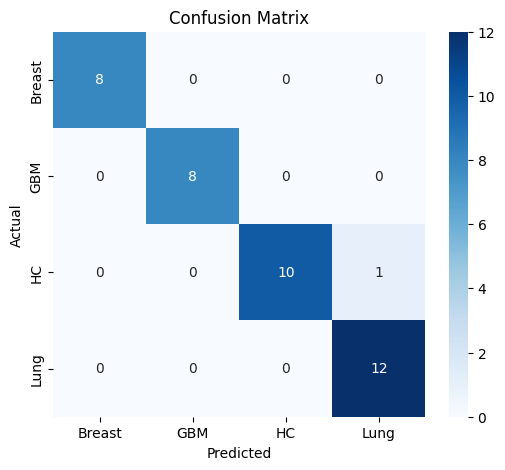

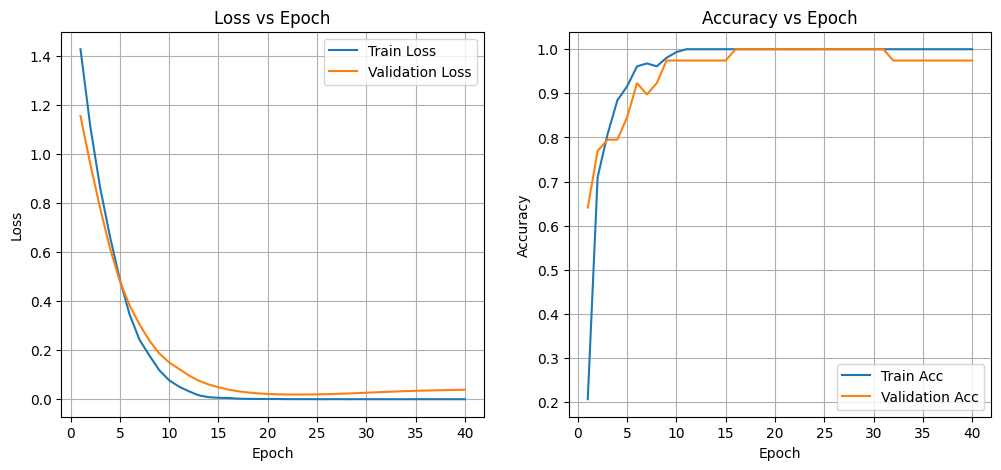


=== OPTIMIZATION RESULTS ===
Number of finished trials: 50
Best trial found:
Best Weighted F1-Score: 0.9290322580645162
Best Parameters: {'hidden': 512, 'embed': 256, 'batch': 16, 'lr': 0.0015211906530058898, 'wd': 0.0009528459947908756, 'mask_ratio': 0.1994700225467981}
hidden_size: 512
lr (learning rate): 0.0015211906530058898
batch_size: 16
Best Model Parameter Count: 325636


In [ ]:
# ---------------- FINAL TRAINING ----------------
encoder = PAMMEncoder(n_genes, bp["embed"], bp["hidden"]).to(DEVICE)
decoder = PAMMDecoder(bp["embed"], bp["hidden"], n_genes).to(DEVICE)
print("Pretraining final model (pathway-aware masking)...")
pretrain(encoder, decoder, X_train_np, bp["lr"], bp["wd"], bp["batch"], bp["mask_ratio"])

# freeze encoder except fc2 for classifier training
for name, p in encoder.named_parameters():
    p.requires_grad = ("fc2" in name)

clf = ClassifierHead(bp["embed"], n_classes).to(DEVICE)
opt = optim.AdamW(list(clf.parameters()) + list(encoder.fc2.parameters()), lr=bp["lr"], weight_decay=bp["wd"])

EPOCHS_FINAL = 40
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Finetuning classifier on encoder outputs...")
for ep in range(EPOCHS_FINAL):
    encoder.train(); clf.train()
    Z_tr = encoder(torch.tensor(X_train_np).to(DEVICE))
    logits_tr = clf(Z_tr)
    loss_tr = ce(logits_tr, torch.tensor(y_train_np).to(DEVICE))
    opt.zero_grad(); loss_tr.backward(); opt.step()

    train_losses.append(loss_tr.item())
    preds_tr = torch.argmax(logits_tr, 1).cpu().numpy()
    train_accs.append(accuracy_score(y_train_np, preds_tr))

    encoder.eval(); clf.eval()
    with torch.no_grad():
        Z_val = encoder(torch.tensor(X_test_np).to(DEVICE))
        logits_val = clf(Z_val)
        loss_val = ce(logits_val, torch.tensor(y_test_np).to(DEVICE))
        val_losses.append(loss_val.item())
        preds_val = torch.argmax(logits_val, 1).cpu().numpy()
        val_accs.append(accuracy_score(y_test_np, preds_val))

    if (ep+1) % 5 == 0 or ep == 0:
        print(f"Epoch {ep+1}/{EPOCHS_FINAL} | Train Loss {loss_tr.item():.4f} | Val Loss {loss_val.item():.4f} | Train Acc {train_accs[-1]:.4f} | Val Acc {val_accs[-1]:.4f}")

# ---------------- TEST EVALUATION ----------------
encoder.eval(); clf.eval()
with torch.no_grad():
    start_inf = time.time()
    Z_test = encoder(torch.tensor(X_test_np).to(DEVICE))
    logits_test = clf(Z_test)
    preds = torch.argmax(logits_test, 1).cpu().numpy()
    end_inf = time.time()

acc = accuracy_score(y_test_np, preds)
print("\n=== Test Results ===")
print("Accuracy:", acc)
print(classification_report(y_test_np, preds, target_names=le.classes_))


# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_test_np, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()


# ---------------- Loss & Accuracy Plots ----------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS_FINAL + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS_FINAL + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS_FINAL + 1), train_accs, label="Train Acc")
plt.plot(range(1, EPOCHS_FINAL + 1), val_accs, label="Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.grid()
plt.legend()

plt.show()


#---------------- Print Optuna Optimization Results ----------------

print("\n=== OPTIMIZATION RESULTS ===")
print("Number of finished trials:", len(study.trials))

best_trial = study.best_trial
print("Best trial found:")
print("Best Weighted F1-Score:", study.best_value)
print("Best Parameters:", best_trial.params)
print("hidden_size:", best_trial.params.get("hidden"))
print("lr (learning rate):", best_trial.params.get("lr"))
print("batch_size:", best_trial.params.get("batch"))

#Best model parameter count

param_count = sum(p.numel() for p in list(encoder.parameters()) + list(clf.parameters()))
print("Best Model Parameter Count:", param_count)

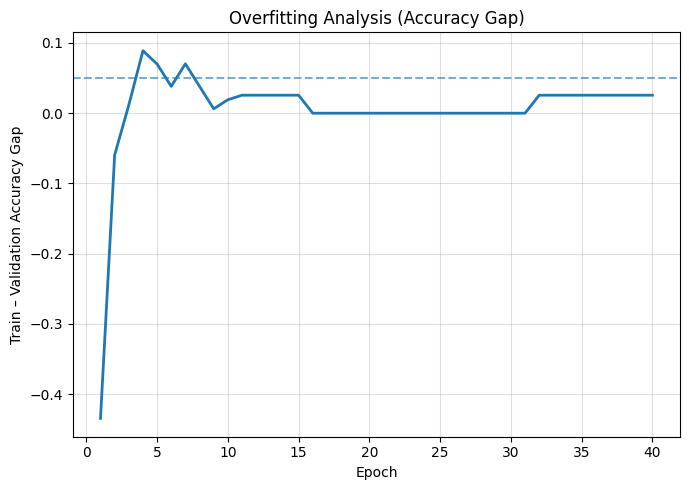

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, EPOCHS_FINAL + 1)
gap = np.array(train_accs) - np.array(val_accs)

plt.figure(figsize=(7,5))
plt.plot(epochs, gap, linewidth=2)

plt.axhline(0.05, linestyle="--", alpha=0.6)

plt.xlabel("Epoch")
plt.ylabel("Train – Validation Accuracy Gap")
plt.title("Overfitting Analysis (Accuracy Gap)")
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
N_RUNS = 20
all_acc = []
all_f1 = []

for run in range(N_RUNS):
    print(f"\n========== RUN {run+1}/{N_RUNS} ==========")

    # recreate models
    encoder = PAMMEncoder(n_genes, bp["embed"], bp["hidden"]).to(DEVICE)
    decoder = PAMMDecoder(bp["embed"], bp["hidden"], n_genes).to(DEVICE)

    # pretrain
    pretrain(encoder, decoder, X_train_np, bp["lr"], bp["wd"], bp["batch"], bp["mask_ratio"])

    # freeze encoder except fc2
    for name, p in encoder.named_parameters():
        p.requires_grad = ("fc2" in name)

    clf = ClassifierHead(bp["embed"], n_classes).to(DEVICE)
    opt = optim.AdamW(list(clf.parameters()) + list(encoder.fc2.parameters()),
                      lr=bp["lr"], weight_decay=bp["wd"])

    # finetune
    for ep in range(EPOCHS_FINAL):
        encoder.train()
        clf.train()
        Z_tr = encoder(torch.tensor(X_train_np).to(DEVICE))
        logits_tr = clf(Z_tr)
        loss_tr = ce(logits_tr, torch.tensor(y_train_np).to(DEVICE))
        opt.zero_grad()
        loss_tr.backward()
        opt.step()

    # test evaluation
    encoder.eval()
    clf.eval()
    with torch.no_grad():
        Z_test = encoder(torch.tensor(X_test_np).to(DEVICE))
        logits_test = clf(Z_test)
        preds = torch.argmax(logits_test, 1).cpu().numpy()

    acc = accuracy_score(y_test_np, preds)
    f1 = f1_score(y_test_np, preds, average="weighted")

    print(f"Run Accuracy = {acc:.4f}, F1 = {f1:.4f}")

    all_acc.append(acc)
    all_f1.append(f1)

# ---- after loop ----
print("\n================ FINAL STATISTICAL REPORT ================")
print("Mean Accuracy:", np.mean(all_acc))
print("Std Accuracy :", np.std(all_acc))
print("Mean F1 Score:", np.mean(all_f1))
print("Std F1 Score :", np.std(all_f1))


========== RUN 1/20 ==========
Pretrain Epoch 1/40 | avg loss: 0.9336
Pretrain Epoch 10/40 | avg loss: 0.3414
Pretrain Epoch 20/40 | avg loss: 0.1539
Pretrain Epoch 30/40 | avg loss: 0.1012
Pretrain Epoch 40/40 | avg loss: 0.1186
Run Accuracy = 1.0000, F1 = 1.0000

========== RUN 2/20 ==========
Pretrain Epoch 1/40 | avg loss: 0.8867
Pretrain Epoch 10/40 | avg loss: 0.3569
Pretrain Epoch 20/40 | avg loss: 0.1680
Pretrain Epoch 30/40 | avg loss: 0.0998
Pretrain Epoch 40/40 | avg loss: 0.0673
Run Accuracy = 1.0000, F1 = 1.0000

========== RUN 3/20 ==========
Pretrain Epoch 1/40 | avg loss: 0.8591
Pretrain Epoch 10/40 | avg loss: 0.3554
Pretrain Epoch 20/40 | avg loss: 0.1625
Pretrain Epoch 30/40 | avg loss: 0.1255
Pretrain Epoch 40/40 | avg loss: 0.0727
Run Accuracy = 1.0000, F1 = 1.0000

========== RUN 4/20 ==========
Pretrain Epoch 1/40 | avg loss: 0.8629
Pretrain Epoch 10/40 | avg loss: 0.3032
Pretrain Epoch 20/40 | avg loss: 0.1845
Pretrain Epoch 30/40 | avg loss: 0.1128
Pretrain Ep

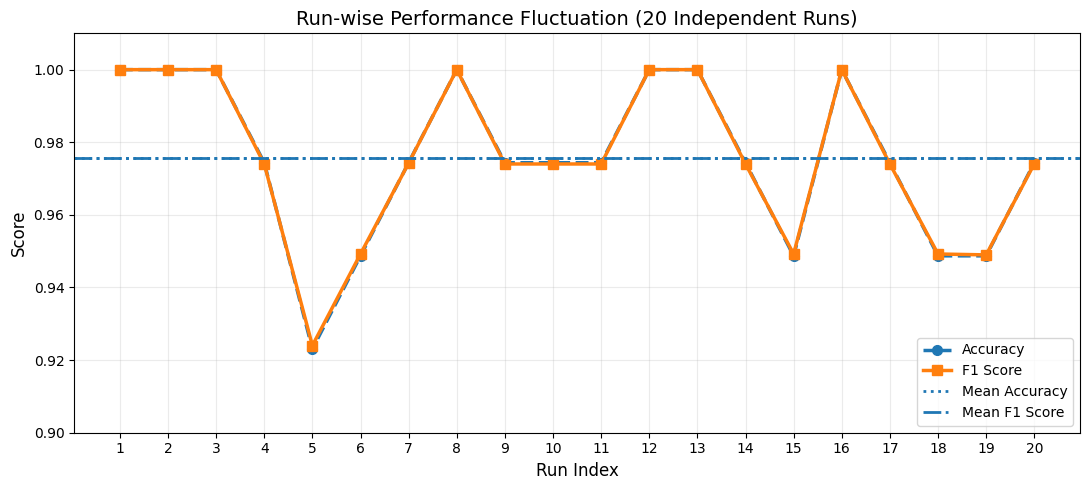

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- DATA ----------------
# all_acc, all_f1 already filled from your training loop
runs = np.arange(1, len(all_acc) + 1)

all_acc = np.array(all_acc)
all_f1  = np.array(all_f1)

# ---------------- PLOT ----------------
plt.figure(figsize=(11, 5))

# Accuracy line
plt.plot(
    runs,
    all_acc,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    markersize=7,
    label='Accuracy'
)

# F1 line
plt.plot(
    runs,
    all_f1,
    marker='s',
    linestyle='-',
    linewidth=2.5,
    markersize=7,
    label='F1 Score'
)

# Mean lines
plt.axhline(
    np.mean(all_acc),
    linestyle=':',
    linewidth=2,
    label='Mean Accuracy'
)

plt.axhline(
    np.mean(all_f1),
    linestyle='-.',
    linewidth=2,
    label='Mean F1 Score'
)

# ---------------- AESTHETICS ----------------
plt.xlabel("Run Index", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Run-wise Performance Fluctuation (20 Independent Runs)", fontsize=14)

plt.ylim(0.90, 1.01)
plt.xticks(runs)
plt.grid(alpha=0.25)
plt.legend(fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# SAVE PAMM METRICS FOR COMPARISON (MULTI-RUN)
# ============================================================

pamm_metrics = {
    "Model": "PAMM",

    # central performance
    "Accuracy": np.mean(all_acc),
    "Macro_F1": np.mean(all_f1),
    "Weighted_F1": np.mean(all_f1),

    # stability & generalization
    "Variance": np.std(all_acc),
    "Overfitting_Gap": np.mean(train_accs) - np.mean(val_accs),

    # robustness indicators
    "Accuracy_STD": np.std(all_acc),
    "F1_STD": np.std(all_f1),

    # reproducibility
    "Runs": N_RUNS
}

pd.DataFrame([pamm_metrics]).to_csv("pamm_metrics.csv", index=False)

print("\nSaved pamm_metrics.csv")
print(pd.DataFrame([pamm_metrics]))



Saved pamm_metrics.csv
  Model  Accuracy  Macro_F1  Weighted_F1  Variance  Overfitting_Gap  \
0  PAMM  0.975641  0.975654     0.975654  0.022169          0.00519   

   Accuracy_STD    F1_STD  Runs  
0      0.022169  0.021959    20  


# Print Cancers and Pathways


## From Real Dataset

In [ ]:
# ============ EXPLAIN FROM MAIN DATASET (LABEL-FREE INPUT) ============

def explain_from_main_dataset(
    row_idx,
    encoder,
    classifier,
    X_full,
    y_full,
    pathway_gene_indices,
    le,
    top_k=5,
    show_true_label=True
):
    """
    Predicts and explains a sample from the MAIN dataset (label not used for prediction).
    """

    encoder.eval()
    classifier.eval()

    if row_idx >= len(X_full):
        raise ValueError("row_idx out of range for main dataset")

    # take single sample (label NOT used)
    x = torch.tensor(X_full[row_idx:row_idx+1], dtype=torch.float32).to(DEVICE)

    # ---- prediction ----
    with torch.no_grad():
        z = encoder(x)
        logits = classifier(z)
        probs = torch.softmax(logits, dim=1)

    pred_class = int(probs.argmax(dim=1).item())
    pred_label = le.classes_[pred_class]
    base_conf = float(probs[0, pred_class].item())

    print("\n================ MODEL PREDICTION & EXPLANATION =================")
    print(f"Dataset Row Index     : {row_idx}")

    if show_true_label:
        print(f"True Label (not used) : {le.classes_[y_full[row_idx]]}")

    print(f"Predicted Cancer      : {pred_label}")
    print(f"Prediction Confidence : {base_conf:.4f}")
    print("---------------------------------------------------------------")

    pathway_impacts = []

    # ---- pathway masking ----
    for pw, idxs in pathway_gene_indices.items():
        if len(idxs) == 0:
            continue

        x_masked = x.clone()
        x_masked[:, idxs] = 0.0

        with torch.no_grad():
            z_pw = encoder(x_masked)
            logits_pw = classifier(z_pw)
            probs_pw = torch.softmax(logits_pw, dim=1)

        new_conf = float(probs_pw[0, pred_class].item())
        drop = base_conf - new_conf

        pathway_impacts.append((pw, drop))

    pathway_impacts.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} Influential Pathways:")
    print("---------------------------------------------------------------")

    for i, (pw, impact) in enumerate(pathway_impacts[:top_k], start=1):
        print(f"{i}. {pw}")
        print(f"   Confidence Drop: {impact:.4f}")

    print("\nModel Claim:")
    print(f"The model predicts **{pred_label}**")
    print("This prediction is driven by activation of:")
    for pw, _ in pathway_impacts[:top_k]:
        print(f"   - {pw}")

    print("===============================================================\n")

explain_from_main_dataset(
    row_idx=85,    # CSV row number
    encoder=encoder,
    classifier=clf,
    X_full=X,       # FULL dataset (labels ignored)
    y_full=y,       # only for display
    pathway_gene_indices=pathway_gene_indices,
    le=le,
    top_k=5
)



================ MODEL PREDICTION & EXPLANATION =================
Dataset Row Index     : 85
True Label (not used) : HC
Predicted Cancer      : HC
Prediction Confidence : 1.0000
---------------------------------------------------------------

Top 5 Influential Pathways:
---------------------------------------------------------------
1. AMPK signaling pathway
   Confidence Drop: 0.0000
2. Adrenergic signaling in cardiomyocytes
   Confidence Drop: 0.0000
3. Alzheimer disease
   Confidence Drop: 0.0000
4. Amoebiasis
   Confidence Drop: 0.0000
5. Amyotrophic lateral sclerosis
   Confidence Drop: 0.0000

Model Claim:
The model predicts **HC**
This prediction is driven by activation of:
   - AMPK signaling pathway
   - Adrenergic signaling in cardiomyocytes
   - Alzheimer disease
   - Amoebiasis
   - Amyotrophic lateral sclerosis



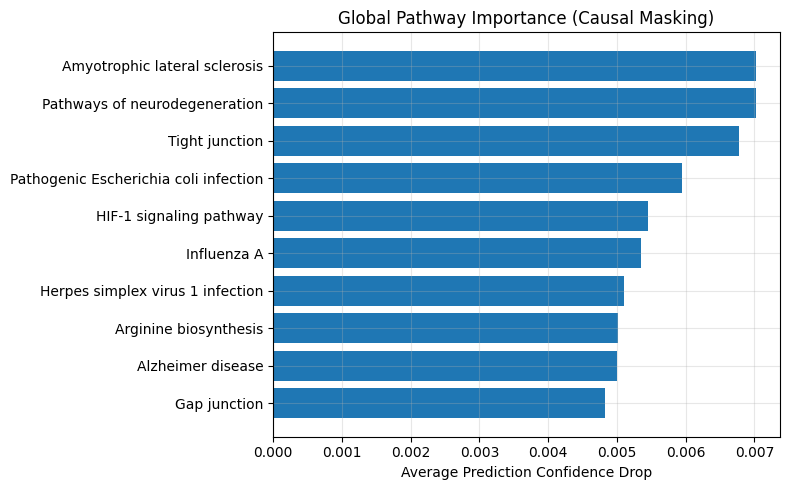

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

def global_pathway_importance(
    encoder,
    classifier,
    X,
    pathway_gene_indices,
    DEVICE,
    max_samples=50   # thesis-friendly, fast
):
    encoder.eval()
    classifier.eval()

    pathway_scores = defaultdict(list)

    for i in range(min(len(X), max_samples)):
        x = torch.tensor(X[i:i+1], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            z = encoder(x)
            logits = classifier(z)
            probs = torch.softmax(logits, dim=1)

        pred_class = int(probs.argmax(dim=1))
        base_conf = float(probs[0, pred_class])

        for pw, idxs in pathway_gene_indices.items():
            if len(idxs) == 0:
                continue

            x_masked = x.clone()
            x_masked[:, idxs] = 0.0

            with torch.no_grad():
                z_pw = encoder(x_masked)
                logits_pw = classifier(z_pw)
                probs_pw = torch.softmax(logits_pw, dim=1)

            new_conf = float(probs_pw[0, pred_class])
            drop = base_conf - new_conf

            pathway_scores[pw].append(drop)

    # average effect
    pathway_avg = {
        pw: np.mean(drops)
        for pw, drops in pathway_scores.items()
    }

    # sort
    pathway_avg = dict(sorted(
        pathway_avg.items(),
        key=lambda x: x[1],
        reverse=True
    ))

    return pathway_avg


pathway_avg = global_pathway_importance(
    encoder=encoder,
    classifier=clf,
    X=X_test_np,          # or full X
    pathway_gene_indices=pathway_gene_indices,
    DEVICE=DEVICE,
    max_samples=50
)

top_k = 10
names = list(pathway_avg.keys())[:top_k]
scores = list(pathway_avg.values())[:top_k]

plt.figure(figsize=(8,5))
plt.barh(names, scores)
plt.xlabel("Average Prediction Confidence Drop")
plt.title("Global Pathway Importance (Causal Masking)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## From Test1 Dataset

In [ ]:
import torch
import numpy as np
import pandas as pd

# ================= DEVICE =================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD TEST CSV (Symbol | ENSG | expression)
# ============================================================

def load_test_csv(csv_path, gene_cols, has_label=True):
    raw = pd.read_csv(csv_path, header=None)

    # row 1 = ENSG IDs
    ensg_ids = raw.iloc[1].astype(str).tolist()

    # row 2+ = expression (+ optional label)
    df = raw.iloc[2:, :].copy()
    df.columns = ensg_ids

    y_true = None
    if has_label and "Cancer_Type" in df.columns:
        y_true = df["Cancer_Type"].values
        df = df.drop(columns=["Cancer_Type"])

    # reorder exactly like training
    df = df[gene_cols]

    X_np = df.astype(np.float32).to_numpy()
    print("Test data loaded:", X_np.shape)

    return X_np, y_true


# ============================================================
# LATENT EXTRACTION
# ============================================================
def extract_latents(encoder, X_np):
    encoder.eval()
    with torch.no_grad():
        X = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        Z = encoder(X).cpu().numpy()
    return Z


# ============================================================
# CLASS CENTROIDS (TRAIN DATA ONLY)
# ============================================================
def compute_class_centroids(Z_train, y_train):
    centroids = {}
    for c in np.unique(y_train):
        centroids[c] = Z_train[y_train == c].mean(axis=0)
    return centroids


# ============================================================
# AUTO CALIBRATION (OPEN-SET THRESHOLDS)
# ============================================================
def auto_calibrate_thresholds(encoder, classifier, X_train_np, centroids):
    encoder.eval()
    classifier.eval()

    with torch.no_grad():
        X = torch.tensor(X_train_np, dtype=torch.float32).to(DEVICE)
        Z = encoder(X)
        logits = classifier(Z)
        probs = torch.softmax(logits, dim=1)

    max_conf = probs.max(dim=1)[0].cpu().numpy()
    Z_np = Z.cpu().numpy()

    min_dists = [
        min(np.linalg.norm(z - centroids[c]) for c in centroids)
        for z in Z_np
    ]

    tau_conf = np.percentile(max_conf, 5)
    tau_dist = np.percentile(min_dists, 95)

    print("Auto-calibration done")
    print(f"τ_conf = {tau_conf:.4f}")
    print(f"τ_dist = {tau_dist:.4f}")

    return tau_conf, tau_dist


# ============================================================
# HYBRID OPEN-SET PREDICTION (FINAL DECISION)
# ============================================================
def hybrid_open_set_predict(
    encoder, classifier, X_np, centroids, le, tau_conf, tau_dist
):
    encoder.eval()
    classifier.eval()

    with torch.no_grad():
        X = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        Z = encoder(X)
        logits = classifier(Z)
        probs = torch.softmax(logits, dim=1)

    Z_np = Z.cpu().numpy()
    probs_np = probs.cpu().numpy()

    rows = []

    for i in range(len(X_np)):
        conf = probs_np[i].max()
        cls = probs_np[i].argmax()
        base_pred = le.classes_[cls]

        min_dist = min(
            np.linalg.norm(Z_np[i] - centroids[c]) for c in centroids
        )

        if conf < tau_conf and min_dist > tau_dist:
            final_pred = "Unknown / Non-cancer"
        else:
            final_pred = base_pred

        rows.append({
            "row_index": i,
            "softmax_confidence": conf,
            "latent_distance": min_dist,
            "prediction": final_pred
        })

    return pd.DataFrame(rows)


# ============================================================
# OPEN-SET AWARE EXPLANATION FUNCTION (CORRECT)
# ============================================================
def explain_from_dataset(
    row_idx,
    encoder,
    classifier,
    X_full,
    pathway_gene_indices,
    le,
    centroids,
    tau_conf,
    tau_dist,
    y_true=None,
    top_k=5
):
    encoder.eval()
    classifier.eval()

    x = torch.tensor(
        X_full[row_idx:row_idx+1],
        dtype=torch.float32
    ).to(DEVICE)

    with torch.no_grad():
        z = encoder(x)
        logits = classifier(z)
        probs = torch.softmax(logits, dim=1)

    probs_np = probs.cpu().numpy()[0]
    z_np = z.cpu().numpy()[0]

    conf = probs_np.max()
    cls = probs_np.argmax()
    base_label = le.classes_[cls]

    min_dist = min(
        np.linalg.norm(z_np - centroids[c]) for c in centroids
    )

    print("\n================ MODEL PREDICTION & EXPLANATION =================")
    print(f"Dataset Row Index     : {row_idx}")
    if y_true is not None:
      print(f"True Label          : {y_true[row_idx]}")
    else:
      print("True Label           : Not available")

    # ---------- OPEN-SET CHECK ----------
    if conf < tau_conf and min_dist > tau_dist:
        print("Final Prediction      : Unknown / Non-cancer")
        print(f"Softmax Confidence    : {conf:.4f}")
        print(f"Latent Distance       : {min_dist:.2f}")
        print("---------------------------------------------------------------")
        print("Reason:")
        print("Low confidence AND far from all known cancer manifolds")
        print("Explanation suppressed (unreliable prediction)")
        print("===============================================================\n")
        return

    # ---------- CLOSED-SET EXPLANATION ----------
    print(f"Final Prediction      : {base_label}")
    print(f"Prediction Confidence : {conf:.4f}")
    print(f"Latent Distance       : {min_dist:.2f}")
    print("---------------------------------------------------------------")

    pathway_impacts = []

    for pw, idxs in pathway_gene_indices.items():
        if len(idxs) == 0:
            continue

        x_masked = x.clone()
        x_masked[:, idxs] = 0.0

        with torch.no_grad():
            z_pw = encoder(x_masked)
            logits_pw = classifier(z_pw)
            probs_pw = torch.softmax(logits_pw, dim=1)

        new_conf = probs_pw[0, cls].item()
        drop = conf - new_conf
        pathway_impacts.append((pw, drop))

    pathway_impacts.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} Influential Pathways:")
    print("---------------------------------------------------------------")
    for i, (pw, drop) in enumerate(pathway_impacts[:top_k], 1):
        print(f"{i}. {pw}")
        print(f"   Confidence Drop: {drop:.4f}")

    print("\nModel Claim:")
    print(f"The model predicts **{base_label}**")
    print("This prediction is driven by activation of:")
    for pw, _ in pathway_impacts[:top_k]:
        print(f"   - {pw}")

    print("===============================================================\n")


# ============================================================
# RUN PIPELINE
# ============================================================

# ---- LOAD TEST DATA ----
X_test_np, y_test_true = load_test_csv(
    "Test1_csv.csv",
    gene_cols,
    has_label=True
)

# ---- TRAIN SIDE ----
Z_train = extract_latents(encoder, X_train_np)
centroids = compute_class_centroids(Z_train, y_train_np)

tau_conf, tau_dist = auto_calibrate_thresholds(
    encoder, clf, X_train_np, centroids
)

# ---- OPEN-SET PREDICTION ----
results_df = hybrid_open_set_predict(
    encoder, clf, X_test_np, centroids, le, tau_conf, tau_dist
)
results_df.to_csv("pamm.csv", index=False)
print("Predictions saved")

# ---- EXPLAIN ONE TEST SAMPLE ----
explain_from_dataset(
    row_idx=3,
    encoder=encoder,
    classifier=clf,
    X_full=X_test_np,
    pathway_gene_indices=pathway_gene_indices,
    le=le,
    centroids=centroids,
    tau_conf=tau_conf,
    tau_dist=tau_dist,
    top_k=5,
    y_true=y_test_true,
)


Test data loaded: (214, 248)
Auto-calibration done
τ_conf = 1.0000
τ_dist = 16.4102
Predictions saved

================ MODEL PREDICTION & EXPLANATION =================
Dataset Row Index     : 3
True Label          : Breast
Final Prediction      : Breast
Prediction Confidence : 1.0000
Latent Distance       : 12.70
---------------------------------------------------------------

Top 5 Influential Pathways:
---------------------------------------------------------------
1. Thyroid hormone signaling pathway
   Confidence Drop: 0.0000
2. Protein processing in endoplasmic reticulum
   Confidence Drop: 0.0000
3. Amyotrophic lateral sclerosis
   Confidence Drop: 0.0000
4. Pathways of neurodegeneration
   Confidence Drop: 0.0000
5. Cysteine and methionine metabolism
   Confidence Drop: 0.0000

Model Claim:
The model predicts **Breast**
This prediction is driven by activation of:
   - Thyroid hormone signaling pathway
   - Protein processing in endoplasmic reticulum
   - Amyotrophic lateral scl

# Top Pathway Plotting for each cancer



Top 10 Pathways for Breast
--------------------------------------------------
1. Parkinson disease | Avg Confidence Drop = 0.001081
2. Prion disease | Avg Confidence Drop = 0.001081
3. Amyotrophic lateral sclerosis | Avg Confidence Drop = 0.001041
4. Pathways of neurodegeneration | Avg Confidence Drop = 0.001041
5. Alzheimer disease | Avg Confidence Drop = 0.001022
6. Huntington disease | Avg Confidence Drop = 0.000935
7. Epstein-Barr virus infection | Avg Confidence Drop = 0.000706
8. Protein processing in endoplasmic reticulum | Avg Confidence Drop = 0.000559
9. Gap junction | Avg Confidence Drop = 0.000547
10. Herpes simplex virus 1 infection | Avg Confidence Drop = 0.000542

Top 10 Pathways for HC
--------------------------------------------------
1. Transcriptional misregulation in cancer | Avg Confidence Drop = 0.000836
2. Influenza A | Avg Confidence Drop = 0.000695
3. Pathogenic Escherichia coli infection | Avg Confidence Drop = 0.000351
4. RNA degradation | Avg Confidence Dro

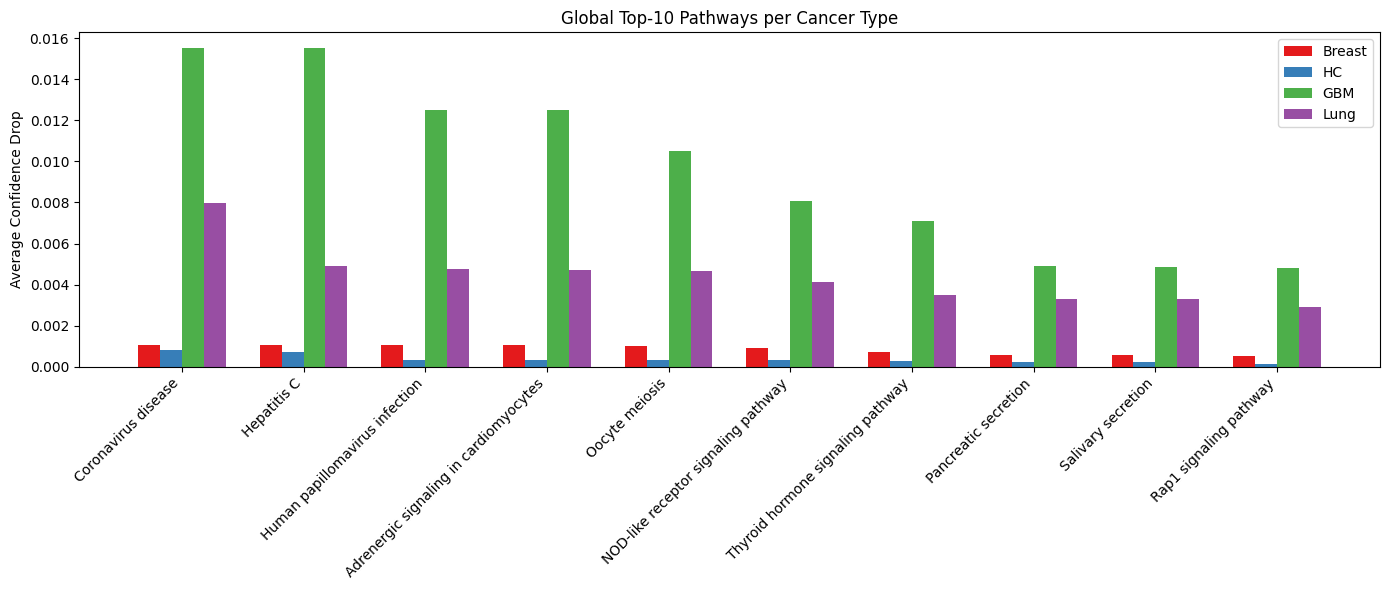

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================
# GLOBAL PATHWAY EXPLANATION
# =========================

def compute_global_pathways(
    cancer_name,
    encoder,
    classifier,
    X_full,
    y_full,
    pathway_gene_indices,
    le,
    top_k=10,
    min_samples=5
):
    encoder.eval()
    classifier.eval()

    cancer_idx = list(le.classes_).index(cancer_name)

    pathway_scores = defaultdict(list)

    for i in range(len(X_full)):
        if y_full[i] != cancer_idx:
            continue

        x = torch.tensor(X_full[i:i+1], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            z = encoder(x)
            logits = classifier(z)
            probs = torch.softmax(logits, dim=1)

        base_conf = probs[0, cancer_idx].item()

        for pw, idxs in pathway_gene_indices.items():
            if len(idxs) == 0:
                continue

            x_masked = x.clone()
            x_masked[:, idxs] = 0.0

            with torch.no_grad():
                z_pw = encoder(x_masked)
                logits_pw = classifier(z_pw)
                probs_pw = torch.softmax(logits_pw, dim=1)

            new_conf = probs_pw[0, cancer_idx].item()
            drop = base_conf - new_conf

            if drop > 0:
                pathway_scores[pw].append(drop)

    # ---- Aggregate ----
    aggregated = []
    for pw, values in pathway_scores.items():
        if len(values) >= min_samples:
            aggregated.append((pw, np.mean(values)))

    aggregated.sort(key=lambda x: x[1], reverse=True)

    return aggregated[:top_k]


# =========================
# RUN FOR MULTIPLE CANCERS
# =========================

cancers = ["Breast", "HC", "GBM", "Lung"]
colors = {
    "Breast": "#e41a1c",
    "HC": "#377eb8",
    "GBM": "#4daf4a",
    "Lung": "#984ea3"
}

results = {}

for cancer in cancers:
    results[cancer] = compute_global_pathways(
        cancer_name=cancer,
        encoder=encoder,
        classifier=clf,
        X_full=X,
        y_full=y,
        pathway_gene_indices=pathway_gene_indices,
        le=le,
        top_k=10
    )

    print(f"\nTop 10 Pathways for {cancer}")
    print("--------------------------------------------------")
    for i, (pw, score) in enumerate(results[cancer], 1):
        print(f"{i}. {pw} | Avg Confidence Drop = {score:.6f}")


# =========================
# PLOT
# =========================

plt.figure(figsize=(14, 6))

offset = 0
width = 0.18

for i, cancer in enumerate(cancers):
    names = [x[0] for x in results[cancer]]
    scores = [x[1] for x in results[cancer]]

    x_pos = np.arange(len(names)) + offset
    plt.bar(
        x_pos,
        scores,
        width=width,
        label=cancer,
        color=colors[cancer]
    )

    offset += width

plt.xticks(
    np.arange(len(names)) + width * 1.5,
    names,
    rotation=45,
    ha="right"
)

plt.ylabel("Average Confidence Drop")
plt.title("Global Top-10 Pathways per Cancer Type")
plt.legend()
plt.tight_layout()
plt.show()


# Unknown Prediction


In [ ]:
import torch
import numpy as np
import pandas as pd

# ================= DEVICE =================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# LATENT EXTRACTION
# ======================================================
def get_latents(encoder, X_np):
    encoder.eval()
    X = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        Z = encoder(X).cpu().numpy()

    return Z


# ======================================================
# CLASS CENTROIDS (TRAIN ONLY)
# ======================================================
def compute_class_centroids(Z_train, y_train):
    centroids = {}
    for c in np.unique(y_train):
        centroids[c] = Z_train[y_train == c].mean(axis=0)
    return centroids


# ======================================================
# AUTO CALIBRATION (TRAIN SET ONLY)
# ======================================================
def auto_calibrate_thresholds(
    encoder,
    classifier,
    X_train_np,
    centroids
):
    encoder.eval()
    classifier.eval()

    X = torch.tensor(X_train_np, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        Z = encoder(X)
        logits = classifier(Z)
        probs = torch.softmax(logits, dim=1)

    # Softmax confidence
    max_confs = probs.max(dim=1)[0].cpu().numpy()

    # Latent distances
    Z_np = Z.cpu().numpy()
    min_dists = []

    for z in Z_np:
        dists = [np.linalg.norm(z - centroids[c]) for c in centroids]
        min_dists.append(min(dists))

    min_dists = np.array(min_dists)

    # Conservative thresholds
    tau_conf = np.percentile(max_confs, 5)   # low confidence
    tau_dist = np.percentile(min_dists, 95)  # far distance

    print("\n===== AUTO CALIBRATION DONE =====")
    print(f"Confidence Threshold (τ₁): {tau_conf:.4f}")
    print(f"Distance Threshold   (τ₂): {tau_dist:.4f}")
    print("================================\n")

    return tau_conf, tau_dist


# ======================================================
# HYBRID OPEN-SET PREDICTION
# ======================================================
def hybrid_predict_csv(
    encoder,
    classifier,
    X_np,
    centroids,
    le,
    tau_conf,
    tau_dist
):
    encoder.eval()
    classifier.eval()

    X = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        Z = encoder(X)
        logits = classifier(Z)
        probs = torch.softmax(logits, dim=1)

    Z_np = Z.cpu().numpy()
    probs_np = probs.cpu().numpy()

    results = []

    for i in range(len(X_np)):
        max_conf = probs_np[i].max()
        pred_class = probs_np[i].argmax()
        pred_label = le.classes_[pred_class]

        dists = [np.linalg.norm(Z_np[i] - centroids[c]) for c in centroids]
        min_dist = min(dists)

        if (max_conf < tau_conf) and (min_dist > tau_dist):
            final_pred = "Unknown / Non-cancer"
        else:
            final_pred = pred_label

        results.append({
            "row_index": i,
            "softmax_confidence": float(max_conf),
            "latent_distance": float(min_dist),
            "prediction": final_pred
        })

    return pd.DataFrame(results)


# ======================================================
# LOAD TEST CSV (3-ROW HEADER SAFE)
# Row 0 → Gene Symbol
# Row 1 → ENSG ID
# Row 2+ → Expression values (+ optional Cancer_Type)
# ======================================================
test_raw = pd.read_csv("Test1_csv.csv", header=None)

# ENSG IDs
ensg_ids = test_raw.iloc[1].values.tolist()

# Expression data
test_df = test_raw.iloc[2:, :]
test_df.columns = ensg_ids

# -------- KEEP TRUE LABEL ONLY FOR OUTPUT --------
if "Cancer_Type" in test_df.columns:
    true_cancer = test_df["Cancer_Type"].values
    test_df = test_df.drop(columns=["Cancer_Type"])
else:
    true_cancer = None

# -------- ENSURE SAME GENE ORDER AS TRAINING --------
test_df = test_df[gene_cols]   # gene_cols from training

X_test_np = test_df.astype(np.float32).to_numpy()

print("Test data shape:", X_test_np.shape)


# ======================================================
# TRAIN LATENTS & CENTROIDS
# ======================================================
Z_train = get_latents(encoder, X_train_np)
centroids = compute_class_centroids(Z_train, y_train_np)


# ======================================================
# AUTO CALIBRATION
# ======================================================
tau_conf, tau_dist = auto_calibrate_thresholds(
    encoder,
    clf,
    X_train_np,
    centroids
)


# ======================================================
# FINAL HYBRID OPEN-SET PREDICTION
# ======================================================
results_df = hybrid_predict_csv(
    encoder,
    clf,
    X_test_np,
    centroids,
    le,
    tau_conf,
    tau_dist
)

# -------- ADD TRUE LABEL (FOR ANALYSIS ONLY) --------
if true_cancer is not None:
    results_df["true_cancer_type"] = true_cancer


# ======================================================
# SAVE OUTPUT
# ======================================================
results_df.to_csv("pamm_open_set_predictions.csv", index=False)


Test data shape: (214, 248)

===== AUTO CALIBRATION DONE =====
Confidence Threshold (τ₁): 1.0000
Distance Threshold   (τ₂): 16.4102



# Comparison with Logistic Regression, SVM, MLP, Random Forest and XGBoost

In [ ]:
# ====================================
# BASELINE MODELS FOR PAMM COMPARISON
# ====================================

import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ---------------- SETTINGS ----------------
DATA_PATH = "Final_CSV.csv"
RANDOM_SEED = 42
TEST_SIZE = 0.2
N_SPLITS = 5

np.random.seed(RANDOM_SEED)

# ---------------- LOAD DATA ----------------
df = pd.read_csv(DATA_PATH)

label_col = "Cancer_Type"
gene_cols = [c for c in df.columns if c != label_col]

X = df[gene_cols].values.astype(np.float32)
y_raw = df[label_col].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

# ---------------- TRAIN–TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED
)

n_classes = len(np.unique(y))

print("Samples :", X.shape[0])
print("Genes   :", X.shape[1])
print("Classes :", le.classes_)

# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        probability=False,
        class_weight="balanced"
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",   # prediction like PAMM
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=200,
        random_state=RANDOM_SEED
    )
}

# ============================================================
# CROSS-VALIDATION + TEST EVALUATION
# ============================================================

results = []

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED
)

for name, model in models.items():
    print(f"\n========== {name} ==========")

    cv_acc = []
    cv_f1 = []

    start_time = time.time()

    # ----- Cross-validation (train split only) -----
    for tr, va in skf.split(X_train, y_train):
        model.fit(X_train[tr], y_train[tr])
        preds = model.predict(X_train[va])

        cv_acc.append(accuracy_score(y_train[va], preds))
        cv_f1.append(f1_score(y_train[va], preds, average="weighted"))

    # ----- Final test evaluation -----
    model.fit(X_train, y_train)
    test_preds = model.predict(X_test)

    test_acc = accuracy_score(y_test, test_preds)
    test_f1  = f1_score(y_test, test_preds, average="weighted")

    runtime = time.time() - start_time

    results.append({
        "Model": name,
        "Accuracy": test_acc,
        "Weighted_F1": test_f1,
        "CV_Mean_Accuracy": np.mean(cv_acc),
        "Variance": np.std(cv_acc),
        "Overfitting_Gap": np.mean(cv_acc) - test_acc,
        "Runtime_sec": runtime
    })

    print(f"Test Accuracy     : {test_acc:.4f}")
    print(f"Weighted F1       : {test_f1:.4f}")
    print(f"CV Mean Accuracy  : {np.mean(cv_acc):.4f}")
    print(f"Overfitting Gap   : {np.mean(cv_acc) - test_acc:.4f}")

# ============================================================
# SAVE RESULTS
# ============================================================

baseline_df = pd.DataFrame(results)
baseline_df.to_csv("baseline_detailed_metrics.csv", index=False)

print("\nSaved: baseline_detailed_metrics.csv")
print(baseline_df)


Samples : 194
Genes   : 248
Classes : ['Breast' 'GBM' 'HC' 'Lung']

========== LogisticRegression ==========
Test Accuracy     : 0.9744
Weighted F1       : 0.9740
CV Mean Accuracy  : 0.9484
Overfitting Gap   : -0.0260

========== SVM_RBF ==========
Test Accuracy     : 0.9487
Weighted F1       : 0.9486
CV Mean Accuracy  : 0.8903
Overfitting Gap   : -0.0584

========== RandomForest ==========
Test Accuracy     : 0.8718
Weighted F1       : 0.8591
CV Mean Accuracy  : 0.7806
Overfitting Gap   : -0.0911

========== XGBoost ==========
Test Accuracy     : 0.8718
Weighted F1       : 0.8657
CV Mean Accuracy  : 0.8194
Overfitting Gap   : -0.0524

========== MLP ==========
Test Accuracy     : 0.9744
Weighted F1       : 0.9740
CV Mean Accuracy  : 0.9097
Overfitting Gap   : -0.0647

Saved: baseline_detailed_metrics.csv
                Model  Accuracy  Weighted_F1  CV_Mean_Accuracy  Variance  \
0  LogisticRegression  0.974359     0.974017          0.948387  0.043757   
1             SVM_RBF  0.948718

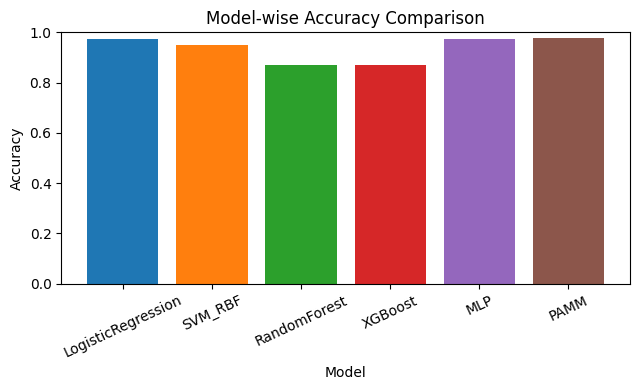

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================= LOAD FILES =================
base = pd.read_csv("baseline_detailed_metrics.csv")
pamm = pd.read_csv("pamm_metrics.csv")

# ================= KEEP COMMON COLUMNS =================
base_plot = base[["Model", "Accuracy"]].copy()
pamm_plot = pamm[["Model", "Accuracy"]].copy()

# ================= COMBINE =================
df = pd.concat([base_plot, pamm_plot], ignore_index=True)

# consistent order
order = [
    "LogisticRegression",
    "SVM_RBF",
    "RandomForest",
    "XGBoost",
    "MLP",
    "PAMM"
]

df["Model"] = pd.Categorical(df["Model"], categories=order, ordered=True)
df = df.sort_values("Model")

# ================= PLOT =================
plt.figure(figsize=(6.5, 4))

# ---- draw bars one by one (default color cycle applies) ----
for i, row in df.iterrows():
    plt.bar(row["Model"], row["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model-wise Accuracy Comparison")

plt.xticks(rotation=25)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


## PAMM vs Logistic Regression

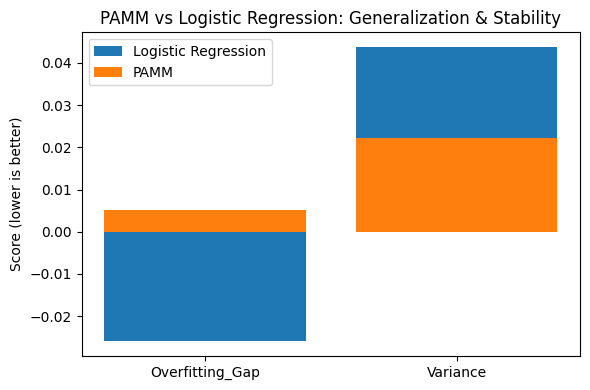

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

base = pd.read_csv("baseline_detailed_metrics.csv")
pamm = pd.read_csv("pamm_metrics.csv")

lr = base[base["Model"]=="LogisticRegression"]
p = pamm.iloc[0]

labels = ["Overfitting_Gap", "Variance"]
lr_vals = [lr[l].values[0] for l in labels]
pamm_vals = [p[l] for l in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, lr_vals, label="Logistic Regression")
plt.bar(labels, pamm_vals, label="PAMM")

plt.ylabel("Score (lower is better)")
plt.title("PAMM vs Logistic Regression: Generalization & Stability")
plt.legend()
plt.tight_layout()
plt.show()


## PAMM vs SVM

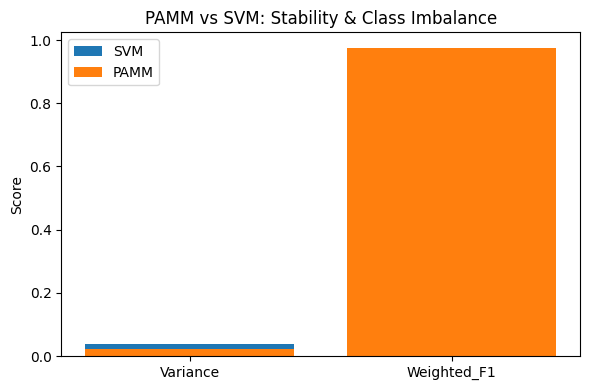

In [ ]:
svm = base[base["Model"]=="SVM_RBF"]

labels = ["Variance", "Weighted_F1"]
svm_vals = [svm[l].values[0] for l in labels]
pamm_vals = [p[l] for l in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, svm_vals, label="SVM")
plt.bar(labels, pamm_vals, label="PAMM")

plt.ylabel("Score")
plt.title("PAMM vs SVM: Stability & Class Imbalance")
plt.legend()
plt.tight_layout()
plt.show()


## PAMM vs Random Forest

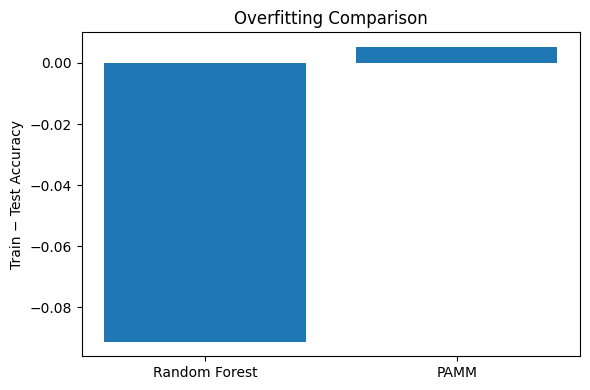

In [ ]:
rf = base[base["Model"]=="RandomForest"]

plt.figure(figsize=(6,4))
plt.bar(["Random Forest", "PAMM"],
        [rf["Overfitting_Gap"].values[0], p["Overfitting_Gap"]])

plt.ylabel("Train − Test Accuracy")
plt.title("Overfitting Comparison")
plt.tight_layout()
plt.show()


## PAMM vs XGBoost

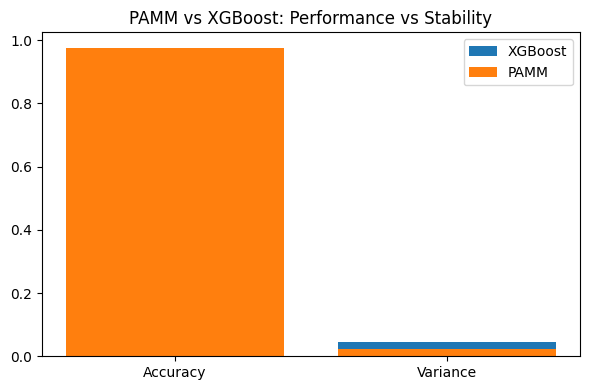

In [ ]:
xgb = base[base["Model"]=="XGBoost"]

labels = ["Accuracy", "Variance"]
xgb_vals = [xgb[l].values[0] for l in labels]
pamm_vals = [p[l] for l in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, xgb_vals, label="XGBoost")
plt.bar(labels, pamm_vals, label="PAMM")

plt.title("PAMM vs XGBoost: Performance vs Stability")
plt.legend()
plt.tight_layout()
plt.show()


## PAMM vs MLP

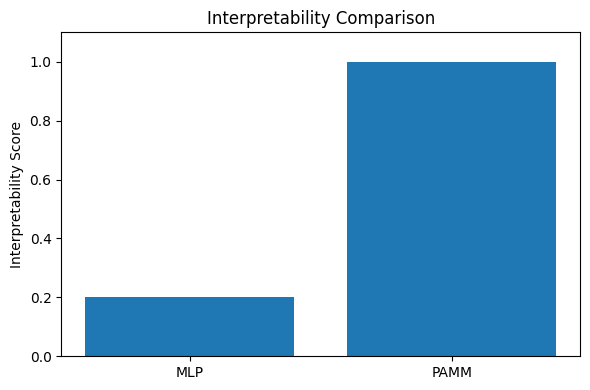

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["MLP", "PAMM"], [0.2, 1.0])
plt.ylabel("Interpretability Score")
plt.title("Interpretability Comparison")
plt.ylim(0,1.1)
plt.tight_layout()
plt.show()


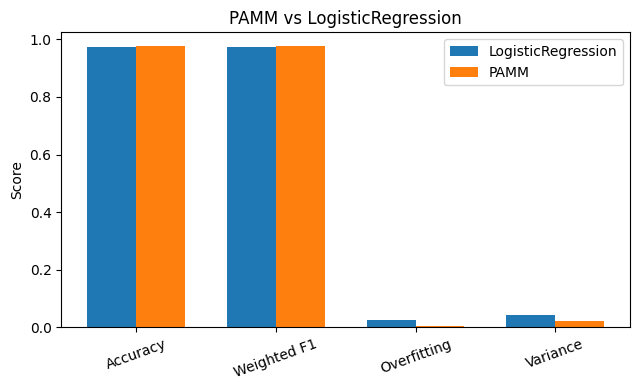

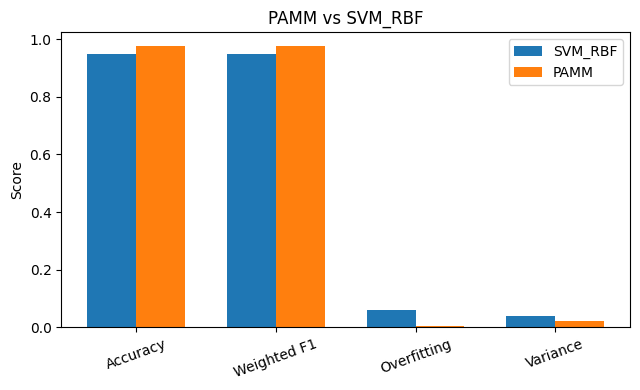

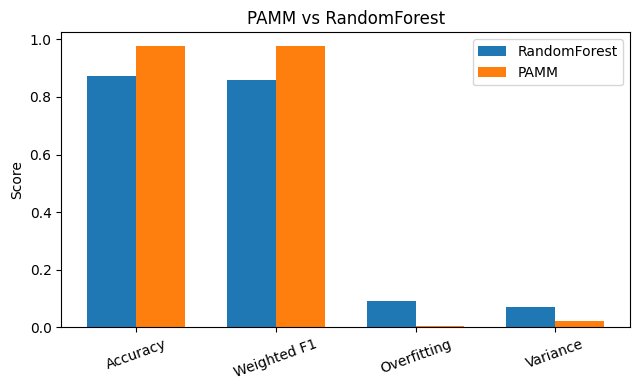

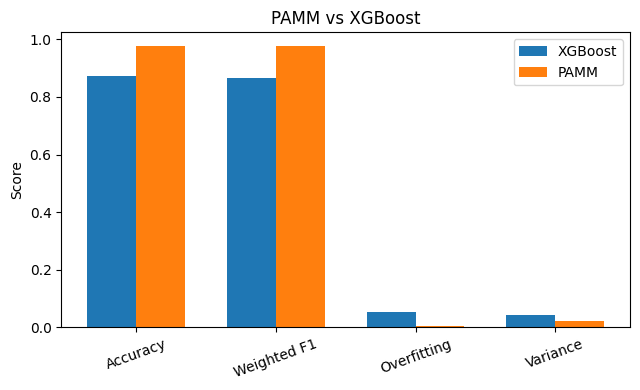

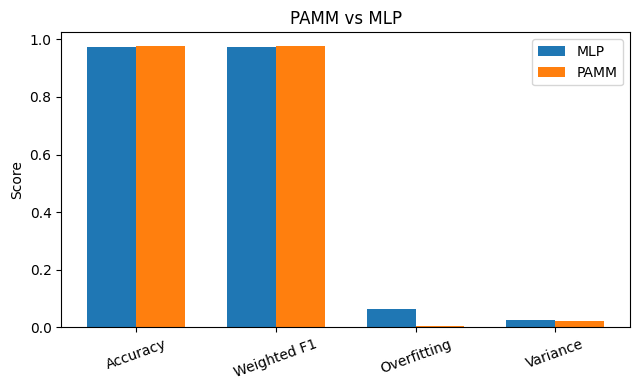

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = pd.read_csv("baseline_detailed_metrics.csv")
pamm = pd.read_csv("pamm_metrics.csv").iloc[0]

def plot_pamm_vs(model_name):

    b = base[base["Model"] == model_name].iloc[0]

    metrics = {
        "Accuracy": (b["Accuracy"], pamm["Accuracy"]),
        "Weighted F1": (b["Weighted_F1"], pamm["Weighted_F1"]),
        "Overfitting": (abs(b["Overfitting_Gap"]), abs(pamm["Overfitting_Gap"])),
        "Variance": (b["Variance"], pamm["Variance"])
    }

    labels = list(metrics.keys())
    base_vals = [metrics[k][0] for k in labels]
    pamm_vals = [metrics[k][1] for k in labels]

    x = np.arange(len(labels))
    w = 0.35

    plt.figure(figsize=(6.5,4))
    plt.bar(x - w/2, base_vals, w, label=model_name)
    plt.bar(x + w/2, pamm_vals, w, label="PAMM")

    plt.xticks(x, labels, rotation=20)
    plt.ylabel("Score")
    plt.title(f"PAMM vs {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for m in base["Model"].unique():
    plot_pamm_vs(m)


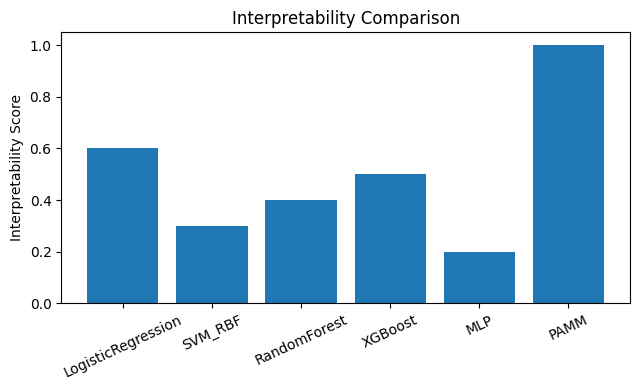

In [ ]:
interpretability = {
    "LogisticRegression": 0.6,
    "SVM_RBF": 0.3,
    "RandomForest": 0.4,
    "XGBoost": 0.5,
    "MLP": 0.2,
    "PAMM": 1.0
}

plt.figure(figsize=(6.5,4))
plt.bar(interpretability.keys(), interpretability.values())
plt.ylabel("Interpretability Score")
plt.title("Interpretability Comparison")
plt.xticks(rotation=25)
plt.ylim(0,1.05)
plt.tight_layout()
plt.show()
